# Image processing, pt 1

## Libraries

Libraries are packages of code that people have written, and can be loaded. 

We'll be using code for plotting, importing files, and image analysis.

In [25]:
# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns
# Library to load tiff files
import tifffile as tiff
# General math libraries
import numpy as np
from scipy import stats
# Image analysis libraries/modules
import skimage as sk
from scipy import ndimage

## Segmentation and thresholding

### Segmentation

A computer doesn't "know" what biological features are, unless we explicitly program it. For example, if we want to analyze cells, we'll need to be able to create a computer program that first of all knows which of the pixel of an image belong to a (single) cell.

Creating such regions of interest (ROIs) in an image is called segmentation.

### Case 1: segmenting an image with bimodal intensity profile


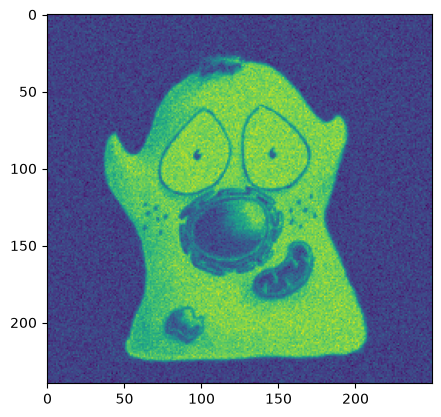

In [40]:
# Load the image using tiff library
img_happycell = tiff.imread("images/happy_cell_noise.tif")

_ = plt.imshow(img_happycell)

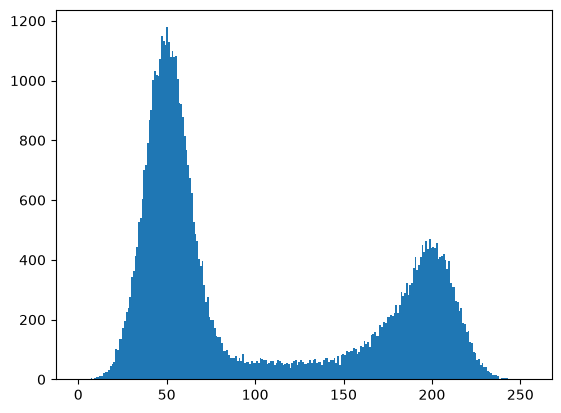

In [41]:
# Show the histogram
_ = plt.hist(img_happycell.ravel(), bins=256)

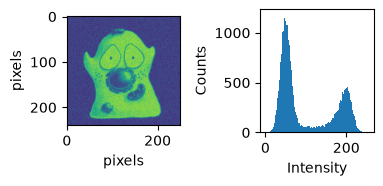

In [27]:


# Create a figure to display the image and it's histogram
fig, axs = plt.subplots(1,2, figsize=(10/2.54, 5/2.54))
_ = axs[0].imshow(img_happycell)
_ = axs[0].set_xlabel("pixels")
_ = axs[0].set_ylabel("pixels")
_ = axs[1].hist(img_happycell.ravel(), bins=256)
_ = axs[1].set_xlabel("Intensity")
_ = axs[1].set_ylabel("Counts")
_ = plt.tight_layout()

The intensity distribution of this image is called "bimodal", since it has two peaks.

#### Intermezzo: using functions

In [28]:
# To avoid re-writing code, create a function that does the same
def plot_img_and_hist(img):
    
    """Create a figure to display the image and it's histogram"""
    
    fig, axs = plt.subplots(1,2, figsize=(10/2.54, 5/2.54))
    # Plot image
    _ = axs[0].imshow(img)
    _ = axs[0].set_xlabel("pixels")
    _ = axs[0].set_ylabel("pixels")
    # Plot histogram
    _ = axs[1].hist(img.ravel(), bins=256)
    _ = axs[1].set_xlabel("Intensity")
    _ = axs[1].set_ylabel("Counts")
    _ = plt.tight_layout()

    return fig, axs

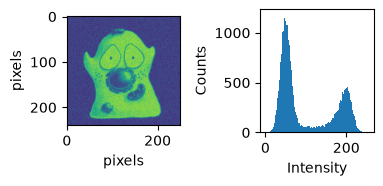

In [29]:
# And now call that function to test it
_, _ = plot_img_and_hist(img_happycell)

In [30]:
# A function is a piece of code that you can run by 
# typing the function name.
# It has inputs (arguments), and an output (return value).

# Function definition, the arguments, which you 
# can freely name, are between round brackets
def add_ab(a, b):
    # Documentation can go between three quotes.
    """ Return the sum of a and b. """

    # Some code
    c = a + b

    # Say what should be returned
    return c

# Now the function can be "called" by it's name, and it 
# will "return" the chosen values.
add_ab(2, 5)

7

***Source materials:** img_happycell is taken from [biobook](https://bioimagebook.github.io/chapters/2-processing/3-thresholding/thresholding.html) (fig. 68), [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).*

#### The segmentation

One algorithm that works well on bimodal distributions is Otsu's method. It will try to find a threshold
that minimizes the variance in the intensities that respectively fall above
and below that threshold. 
(For more info, see [biobook](https://bioimagebook.github.io/chapters/2-processing/3-thresholding/thresholding.html).)

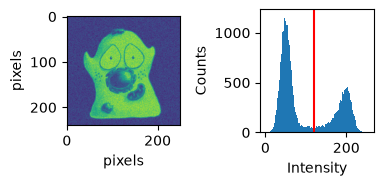

In [42]:
# Call the function to determine the otsu threshold from scikit image
thresh_otsu = sk.filters.threshold_otsu(img_happycell)
# Plot the result
fig, axs = plot_img_and_hist(img_happycell)
_ = axs[1].axvline(thresh_otsu, color="red")

In [ ]:
# We can create a "mask", a binary image that represent 
# foreground and background
mask_happycell = img_happycell>thresh_otsu
# Inspecting what we did
mask_happycell[50:100, 50:100]

array([[False, False, False, ...,  True,  True,  True],
       [False, False, False, ...,  True,  True,  True],
       [False, False, False, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]], shape=(50, 50))

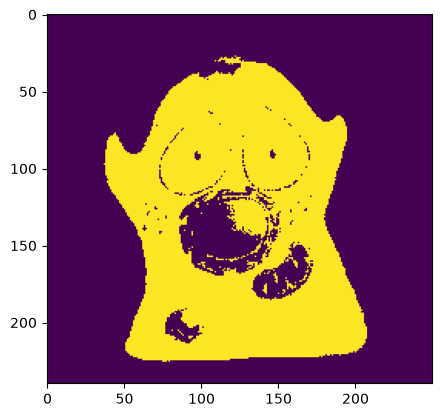

In [43]:
_ = plt.imshow(mask_happycell)

### Case 2: segmenting an image with a dominant background

In [ ]:
tiff.imread("images/KTR_t0.tif")

## Masks, labels and regions

## Convolutional image operations